# Group 02: AI-Powered Product Search Platform

**Team member introduction**

* 1. Luong Nguyen Dinh - 0944370237 - dinh.luong03@hcmut.edu.vn
* 2. Duong Hoang Yen - 0935725591 - yen.duonghoang@hcmut.edu.vn
* 3. Huynh Cong Thien - 0832244772 - thien.huynhhct280503@hcmut.edu.vn

## 1. Install Libraries

In [ ]:
# Install the required library versions
!pip install -q \
datasets==2.21.0 \
evidently>=0.4.36 \
pandas>=2.2.2 \
pillow>=10.3.0 \
plotly>=5.22.0 \
pydantic>=2.7.0 \
pydantic-settings>=2.2.1 \
torch==2.3.0 \
torchvision==0.18.0 \
torchaudio==2.3.0 \
transformers==4.41.2 \
pyarrow>=16.1.0 \
fastparquet>=2024.5.0 \
imagehash

# Verify the installed versions after installation.
import os
import json
import random
import hashlib
from io import BytesIO
from collections import Counter

import requests
import pandas as pd
import matplotlib.pyplot as plt
import imagehash
import datasets
import torch
import torchvision
import transformers

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, Image as IPImage

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    CLIPProcessor,
    CLIPModel,
    get_cosine_schedule_with_warmup,
)

print(f"--- System Version Verification ---")
print(f"Pandas version:      {pd.__version__}")
print(f"Datasets version:    {datasets.__version__}")
print(f"PyTorch version:     {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
--- Xác nhận phiên bản hệ thống ---
Pandas version:      2.2.2
Datasets version:    2.21.0
PyTorch version:     2.3.0+cu121
Transformers version: 4.41.2


In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: Tesla T4


## 2. Mount Google Drive (lưu checkpoint + index)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/clip_amazon_retrieval'
IMG_DIR     = os.path.join(PROJECT_DIR, 'images')
CKPT_DIR    = os.path.join(PROJECT_DIR, 'checkpoints')
INDEX_DIR   = os.path.join(PROJECT_DIR, 'index')
for d in [IMG_DIR, CKPT_DIR, INDEX_DIR]:
    os.makedirs(d, exist_ok=True)
print('Project dir:', PROJECT_DIR)

Mounted at /content/drive
Project dir: /content/drive/MyDrive/clip_amazon_retrieval


## 3. Load Metadata from Amazon-Reviews-2023

The dataset is very large, so we use `streaming=True` and only load one category.  
Change `CATEGORY` to try other categories (see the category list on the Hugging Face dataset page, e.g., `All_Beauty`, `Electronics`, `Toys_and_Games`, ...).

Each metadata item contains fields such as: `parent_asin`, `title`, `description`, `images` (a list of image URLs with different resolutions), `categories`, ...

In [ ]:
from datasets import load_dataset
hf_dataset_path = "McAuley-Lab/Amazon-Reviews-2023"
subset  = "raw_meta_Amazon_Fashion"

ds_meta = load_dataset(
    hf_dataset_path,
    name=subset,
    split="full",
    trust_remote_code=True,
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

In [ ]:
# Peek at one sample to inspect the structure
sample = next(iter(ds_meta))
for k, v in sample.items():
    s = str(v)
    print(f'{k}: {s[:200]}{"..." if len(s) > 200 else ""}')

main_category: AMAZON FASHION
title: YUEDGE 5 Pairs Men's Moisture Control Cushioned Dry Fit Casual Athletic Crew Socks for Men (Blue, Size 9-12)
average_rating: 4.6
rating_number: 16
features: []
description: []
price: None
images: {'hi_res': ['https://m.media-amazon.com/images/I/81XlFXImFrS._AC_UL1500_.jpg', 'https://m.media-amazon.com/images/I/61+yVkHHQ3S._AC_UL1200_.jpg', 'https://m.media-amazon.com/images/I/61vbh6sLR1L._AC_U...
videos: {'title': [], 'url': [], 'user_id': []}
store: GiveGift
categories: []
details: {"Package Dimensions": "10.31 x 8.5 x 1.73 inches; 14.82 Ounces", "Item model number": "DHES5PM21DH12", "Date First Available": "February 12, 2021"}
parent_asin: B08BHN9PK5
bought_together: None
subtitle: None
author: None


In [ ]:
len(ds_meta)

826108

## 4. Download Images + Build (image_path, caption) Records

In [ ]:
N_SAMPLES     = 5000
MIN_TITLE_LEN = 10

def pick_image_url(images_field):
    if not images_field:
        return None

    if isinstance(images_field, dict):
        for key in ['large', 'hi_res', 'thumb']:
            urls = images_field.get(key) or []
            for u in urls:
                if u:
                    return u
        return None
    if isinstance(images_field, list):
        for img in images_field:
            if isinstance(img, dict):
                for key in ['large', 'hi_res', 'thumb']:
                    if img.get(key):
                        return img[key]
            elif isinstance(img, str):
                return img
    return None

def make_caption(item):
    title = (item.get('title') or '').strip()
    desc  = item.get('description') or []
    if isinstance(desc, list):
        desc = ' '.join([d for d in desc if isinstance(d, str)])
    desc = (desc or '').strip()
    caption = title if not desc else f'{title}. {desc}'
    return caption[:300]

def download_image(url, save_path, timeout=10):
    if os.path.exists(save_path):
        return True
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return False
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img.save(save_path, 'JPEG', quality=90)
        return True
    except Exception:
        return False

records = []
pbar = tqdm(total=N_SAMPLES, desc='Downloading')
for item in ds_meta:
    if len(records) >= N_SAMPLES:
        break
    url = pick_image_url(item.get('images'))
    cap = make_caption(item)
    if not url or len(cap) < MIN_TITLE_LEN:
        continue
    asin = item.get('parent_asin') or hashlib.md5(url.encode()).hexdigest()[:12]
    save_path = os.path.join(IMG_DIR, f'{asin}.jpg')
    if download_image(url, save_path):
        records.append({'asin': asin, 'image': save_path, 'caption': cap})
        pbar.update(1)
pbar.close()

print(f'Total records: {len(records)}')


Downloading:   0%|          | 0/5000 [00:00<?, ?it/s]

Total records: 5000


In [ ]:
CATEGORY = "Amazon_Fashion"
META_PATH = os.path.join(PROJECT_DIR, f'records_{CATEGORY}.json')

print("-> Scanning the visual structure of all images to automatically detect placeholder images...")
hash_list = []
valid_records = []
removed_images_log = []  # Store logs containing the actual image file paths

# 1. Calculate Perceptual Hash (pHash)
for rec in tqdm(records, desc="Calculating pHash"):
    img_path = rec['image']
    if os.path.exists(img_path):
        try:
            with Image.open(img_path) as img:
                h = str(imagehash.phash(img))
                hash_list.append(h)
                rec['phash'] = h
                valid_records.append(rec)
        except Exception:
            if os.path.exists(img_path):
                os.remove(img_path)

if hash_list:
    hash_counts = Counter(hash_list)
    cleaned_records = valid_records.copy()
    removed_count = 0

    for most_common_hash, count in hash_counts.most_common(3):
        if count > 5:
            print(f"\n[ANALYSIS] Detected a cluster of corrupted/placeholder images with hash: {most_common_hash} (Duplicated {count} times).")

            target_hash = imagehash.hex_to_hash(most_common_hash)
            temp_records = []

            for rec in cleaned_records:
                if 'phash' in rec:
                    current_hash = imagehash.hex_to_hash(rec['phash'])
                    if current_hash - target_hash <= 4:
                        # Save information including the actual existing image file path
                        removed_images_log.append({
                            'path': rec['image'],
                            'asin': rec['asin'],
                            'caption': rec['caption']
                        })
                        removed_count += 1
                    else:
                        temp_records.append(rec)
                else:
                    temp_records.append(rec)

            cleaned_records = temp_records

    for rec in cleaned_records:
        if 'phash' in rec:
            del rec['phash']

    print(f"\n➔ Scan completed! Detected a total of {removed_count} corrupted/placeholder images.")
    print(f"➔ Number of CLEAN samples ready for training: {len(cleaned_records)} samples.")
    records = cleaned_records
else:
    print("No valid image data found for processing.")

# 3. Overwrite the cleaned metadata JSON file
with open(META_PATH, 'w') as f:
    json.dump(records, f)

print(f'➔ Successfully updated the cleaned metadata file at: {META_PATH}')

-> Scanning the visual structure of all images to automatically detect placeholder images...


Calculating pHash:   0%|          | 0/5000 [00:00<?, ?it/s]


[ANALYSIS] Detected a cluster of corrupted/placeholder images with hash: ef2f949635d1c068 (Duplicated 59 times).

➔ Scan completed! Detected a total of 59 corrupted/placeholder images.
➔ Number of CLEAN samples ready for training: 4941 samples.
➔ Successfully updated the cleaned metadata file at: /content/drive/MyDrive/clip_amazon_retrieval/records_Amazon_Fashion.json


   DETAILED LIST AND REAL IMAGE PREVIEW OF 59 REMOVED INVALID FILES

[1] Processing junk file: B072MDJ9N2.jpg
    - Product Identifier (ASIN): B072MDJ9N2
    - Caption: Multi Focus Progressive Reading Glasses 3 Powers in 1 Reader Rectangle Half Rim (bronze, 2)
    - [ACTUAL IMAGE FROM THE DATASET]:


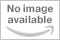

---------------------------------------------------------------------------

[2] Processing junk file: B08H1Y77B2.jpg
    - Product Identifier (ASIN): B08H1Y77B2
    - Caption: Amikadom Christmas Women Dress
    - [ACTUAL IMAGE FROM THE DATASET]:


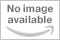

---------------------------------------------------------------------------

[3] Processing junk file: B089QN5VWB.jpg
    - Product Identifier (ASIN): B089QN5VWB
    - Caption: ZESICA Women's Long Sleeve Crew Neck Camouflage Printed Knit Casual Loose Pullover Sweater Jumper Tops
    - [ACTUAL IMAGE FROM THE DATASET]:


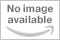

---------------------------------------------------------------------------

[4] Processing junk file: B07CM3SYR7.jpg
    - Product Identifier (ASIN): B07CM3SYR7
    - Caption: LEANI Women's V Neck Ruffle Adjustable Strappy Summer Beach Long Maxi Dress Pink
    - [ACTUAL IMAGE FROM THE DATASET]:


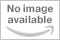

---------------------------------------------------------------------------

[5] Processing junk file: B07HGXS2K3.jpg
    - Product Identifier (ASIN): B07HGXS2K3
    - Caption: Veterinary Technician Vet TECH Caduceus 3D .925 Solid Sterling Silver Charm Ideal Gifts, Pendant, Charms, DIY Crafting, Gift Set from Heart by Wholesale Charms
    - [ACTUAL IMAGE FROM THE DATASET]:


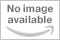

---------------------------------------------------------------------------

[6] Processing junk file: B08TR2JXZX.jpg
    - Product Identifier (ASIN): B08TR2JXZX
    - Caption: BRONGER 20mm 22mm Multi-color Twill Slip-thru Nylon Watch Strap with Stripe Laser Cut Adjustable Seat Belt Watch Band with Slight Brushed Luster on Stainless Steel Buckle for Women or Men(Blue-Orange)
    - [ACTUAL IMAGE FROM THE DATASET]:


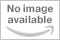

---------------------------------------------------------------------------

[7] Processing junk file: B08TZNLPMH.jpg
    - Product Identifier (ASIN): B08TZNLPMH
    - Caption: Stance Kids Monstropolis Crew Socks (Turquoise, Medium (Kids 11-2))
    - [ACTUAL IMAGE FROM THE DATASET]:


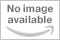

---------------------------------------------------------------------------

[8] Processing junk file: B08XBTSLN2.jpg
    - Product Identifier (ASIN): B08XBTSLN2
    - Caption: ZERDOCEAN Women's Plus Size Pajamas Set Soft Sleepwear Long Sleeve Button Down Nightwear Long Pants Pjs Lounge Sets Darkgray 4X
    - [ACTUAL IMAGE FROM THE DATASET]:


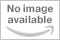

---------------------------------------------------------------------------

[9] Processing junk file: B08YMX1MX3.jpg
    - Product Identifier (ASIN): B08YMX1MX3
    - Caption: dnkplt LGBT t Shirt (XL) Black
    - [ACTUAL IMAGE FROM THE DATASET]:


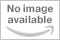

---------------------------------------------------------------------------

[10] Processing junk file: B09QXWNS6H.jpg
    - Product Identifier (ASIN): B09QXWNS6H
    - Caption: Womens Belts for Jeans, Fashion Brown Waist Belt Cute Dress Belt for Women 105cm fit for waist:34"
    - [ACTUAL IMAGE FROM THE DATASET]:


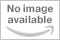

---------------------------------------------------------------------------

[11] Processing junk file: B07ZPVKBT4.jpg
    - Product Identifier (ASIN): B07ZPVKBT4
    - Caption: SheIn Women's Basic Sleeveless Strappy Cami Dress Bodycon Solid Rib Knit Mini Dress Solid Black Medium
    - [ACTUAL IMAGE FROM THE DATASET]:


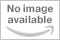

---------------------------------------------------------------------------

[12] Processing junk file: B08312QXYY.jpg
    - Product Identifier (ASIN): B08312QXYY
    - Caption: ODODOS Long Sleeve Workout Shirts for Women, Beige, Small
    - [ACTUAL IMAGE FROM THE DATASET]:


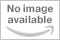

---------------------------------------------------------------------------

[13] Processing junk file: B07YD9P5PC.jpg
    - Product Identifier (ASIN): B07YD9P5PC
    - Caption: Helisopus Womens Baggy Casual Trousers Cotton Linen Loose Harlan Pants Elastic Waist
    - [ACTUAL IMAGE FROM THE DATASET]:


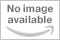

---------------------------------------------------------------------------

[14] Processing junk file: B0751XF8D2.jpg
    - Product Identifier (ASIN): B0751XF8D2
    - Caption: Conceited Premium
    - [ACTUAL IMAGE FROM THE DATASET]:


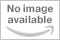

---------------------------------------------------------------------------

[15] Processing junk file: B07N32PGGL.jpg
    - Product Identifier (ASIN): B07N32PGGL
    - Caption: Tamarac by Slippers International Men's Koosh Spa Scuff (16 D(M) US, Rootbeer)
    - [ACTUAL IMAGE FROM THE DATASET]:


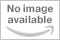

---------------------------------------------------------------------------

[16] Processing junk file: B09QXVRFWD.jpg
    - Product Identifier (ASIN): B09QXVRFWD
    - Caption: Womens Belts for Jeans, Fashion Brown Waist Belt Cute Dress Belt for Women 110cm fit for waist:36"
    - [ACTUAL IMAGE FROM THE DATASET]:


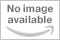

---------------------------------------------------------------------------

[17] Processing junk file: B08MX2XKRW.jpg
    - Product Identifier (ASIN): B08MX2XKRW
    - Caption: MARE AZZURO Bling Reading Glasses Women Trendy Round Readers 0 1.00 1.25 1.50 1.75 2.00 2.25 2.50 2.75 3.00 3.50 4.00 5.00 6.00 (Brown, 2.75)
    - [ACTUAL IMAGE FROM THE DATASET]:


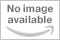

---------------------------------------------------------------------------

[18] Processing junk file: B07FKPYK3K.jpg
    - Product Identifier (ASIN): B07FKPYK3K
    - Caption: Sakuracan Toddler Boys Girls House Slippers Cartoon Dinosaur Warm Home Shoes Indoor Bedroom(12 Little Kid, B-Pink)
    - [ACTUAL IMAGE FROM THE DATASET]:


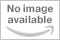

---------------------------------------------------------------------------

[19] Processing junk file: B0B8HBK41S.jpg
    - Product Identifier (ASIN): B0B8HBK41S
    - Caption: Akivide Womens Cotton Linen Long Sleeve Long Dress Button V Neck Tiered Loose High Waist Pleated Flowy Maxi Dress for Women (XX-Large, Green)
    - [ACTUAL IMAGE FROM THE DATASET]:


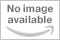

---------------------------------------------------------------------------

[20] Processing junk file: B07DNDC3LT.jpg
    - Product Identifier (ASIN): B07DNDC3LT
    - Caption: Canvas Elastic Fabric Woven Stretch Braided Belts 1.3’’ Wide
    - [ACTUAL IMAGE FROM THE DATASET]:


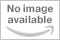

---------------------------------------------------------------------------

[21] Processing junk file: B0B12QTLMN.jpg
    - Product Identifier (ASIN): B0B12QTLMN
    - Caption: Floral Secrets Comfort Rose Bra-Floral Secrets Rose Bra-Secret Floral Bras-Comfort Rose Bra-Floral Secrets No Wire Bra (34/75CDE, Black)
    - [ACTUAL IMAGE FROM THE DATASET]:


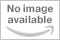

---------------------------------------------------------------------------

[22] Processing junk file: B018JRP0GE.jpg
    - Product Identifier (ASIN): B018JRP0GE
    - Caption: Disney Store Marvel Avengers Iron Man Costume Little Boy 2PC Long Sleeve Pajama Set (3)
    - [ACTUAL IMAGE FROM THE DATASET]:


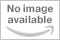

---------------------------------------------------------------------------

[23] Processing junk file: B09MVXFT6V.jpg
    - Product Identifier (ASIN): B09MVXFT6V
    - Caption: Black classic fashion casual business ladies belt women's belts 115cm fit for waist 38"
    - [ACTUAL IMAGE FROM THE DATASET]:


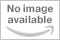

---------------------------------------------------------------------------

[24] Processing junk file: B07LC3WBCW.jpg
    - Product Identifier (ASIN): B07LC3WBCW
    - Caption: Outerstuff Houston Astros Blank Navy Kids Cool Base Alternate Team Jersey (5/6)
    - [ACTUAL IMAGE FROM THE DATASET]:


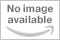

---------------------------------------------------------------------------

[25] Processing junk file: B01LAHJWDW.jpg
    - Product Identifier (ASIN): B01LAHJWDW
    - Caption: FE8 Girl Elsa Snow Queen Dress Frozen Inspired Halloween Kids Costume 4-12 (7/8 - 130)
    - [ACTUAL IMAGE FROM THE DATASET]:


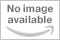

---------------------------------------------------------------------------

[26] Processing junk file: B07HJ7JZKV.jpg
    - Product Identifier (ASIN): B07HJ7JZKV
    - Caption: X.A.X Free Shipping Rhinestone Ladies Watch Small Dial Face Rose Gold Tone Lady Watch
    - [ACTUAL IMAGE FROM THE DATASET]:


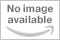

---------------------------------------------------------------------------

[27] Processing junk file: B07VF9JX6G.jpg
    - Product Identifier (ASIN): B07VF9JX6G
    - Caption: oten Women's Casual Split V Neck Loose Fit Long Dress Short Sleeve Pocket Maxi Dresses Navy Blue
    - [ACTUAL IMAGE FROM THE DATASET]:


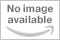

---------------------------------------------------------------------------

[28] Processing junk file: B0888MQ21G.jpg
    - Product Identifier (ASIN): B0888MQ21G
    - Caption: AGUTIUN Men's 3 Pack Muscle Tank Tops Gym Sleeveless Workout Tee Bodybuilding Fitness Shirts
    - [ACTUAL IMAGE FROM THE DATASET]:


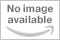

---------------------------------------------------------------------------

[29] Processing junk file: B07PXK84J8.jpg
    - Product Identifier (ASIN): B07PXK84J8
    - Caption: Fashion New High-end Men's Business Myopia Sun Photochromic Lens Metal Half Frame Optical Nearsighted Glasses (-100)
    - [ACTUAL IMAGE FROM THE DATASET]:


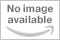

---------------------------------------------------------------------------

[30] Processing junk file: B09P1T4PXL.jpg
    - Product Identifier (ASIN): B09P1T4PXL
    - Caption: Womens Belts for Jeans, Fashion Brown Waist Belt Cute Dress Belt for Women 115cm fit for waist:38"
    - [ACTUAL IMAGE FROM THE DATASET]:


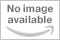

---------------------------------------------------------------------------

[31] Processing junk file: B09VXV96V8.jpg
    - Product Identifier (ASIN): B09VXV96V8
    - Caption: ZESICA Women's Summer Casual Strapless Plaid Print Off Shoulder Backless Ruffle Beach Long Midi Dress,SkyBlue,X-Large
    - [ACTUAL IMAGE FROM THE DATASET]:


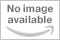

---------------------------------------------------------------------------

[32] Processing junk file: B09Y5PQHB4.jpg
    - Product Identifier (ASIN): B09Y5PQHB4
    - Caption: yiagofy 20pcs Anime Cartoon Shoe Charms for Kids Girls Teens, Anime Shoe Charms Sandals Bracelets Decoration Party Favor
    - [ACTUAL IMAGE FROM THE DATASET]:


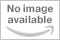

---------------------------------------------------------------------------

[33] Processing junk file: B076CL8TKC.jpg
    - Product Identifier (ASIN): B076CL8TKC
    - Caption: LAI MENG FIVE CATS Women's 3/4 Sleeves Bow Tie A-line Casual Cocktail Swing Skater Dress (10, Black)
    - [ACTUAL IMAGE FROM THE DATASET]:


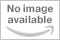

---------------------------------------------------------------------------

[34] Processing junk file: B09R9753N3.jpg
    - Product Identifier (ASIN): B09R9753N3
    - Caption: 60PCS KF94 Mask 50PCS, 3D Fish Type Masks for Adult, Protective Face Shield Mask 4 Layer with Adjustable Nose Clip Men Women Black Grey
    - [ACTUAL IMAGE FROM THE DATASET]:


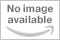

---------------------------------------------------------------------------

[35] Processing junk file: B07KFNCR5Q.jpg
    - Product Identifier (ASIN): B07KFNCR5Q
    - Caption: Hansom Tees Yippee Ki T Shirt (3XL, Sport Gray)
    - [ACTUAL IMAGE FROM THE DATASET]:


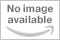

---------------------------------------------------------------------------

[36] Processing junk file: B01GHH6D7S.jpg
    - Product Identifier (ASIN): B01GHH6D7S
    - Caption: Carolbar Women's Zip Ankle Strap Sandy Beach Casual Comfort Sweet Open Toe Low Heel Dress Sandals (15, Black)
    - [ACTUAL IMAGE FROM THE DATASET]:


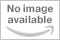

---------------------------------------------------------------------------

[37] Processing junk file: B094Y4JLXS.jpg
    - Product Identifier (ASIN): B094Y4JLXS
    - Caption: Men's Athletic Workout T-Shirt Breathable Comfortable Muscle Running Shirts Training Quick Dry Gym Activewear Gradient Gray L
    - [ACTUAL IMAGE FROM THE DATASET]:


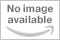

---------------------------------------------------------------------------

[38] Processing junk file: B008RQ2480.jpg
    - Product Identifier (ASIN): B008RQ2480
    - Caption: EL Panel Sound Activated, Light Animated Party T-Shirt - 034 (Medium)
    - [ACTUAL IMAGE FROM THE DATASET]:


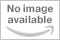

---------------------------------------------------------------------------

[39] Processing junk file: B08PCT69SS.jpg
    - Product Identifier (ASIN): B08PCT69SS
    - Caption: Ritera plus size hoodie
    - [ACTUAL IMAGE FROM THE DATASET]:


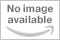

---------------------------------------------------------------------------

[40] Processing junk file: B088FL6CFJ.jpg
    - Product Identifier (ASIN): B088FL6CFJ
    - Caption: YLISHI Sexy Push Up Bra Thin Cup Thin Shoulder Strap Drawstring Women Bras (38C, Beige)
    - [ACTUAL IMAGE FROM THE DATASET]:


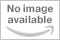

---------------------------------------------------------------------------

[41] Processing junk file: B09M3YH8RF.jpg
    - Product Identifier (ASIN): B09M3YH8RF
    - Caption: Black classic fashion casual business ladies belt women's belts 100cm fit for waist 32"
    - [ACTUAL IMAGE FROM THE DATASET]:


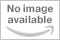

---------------------------------------------------------------------------

[42] Processing junk file: B09MJN6S8K.jpg
    - Product Identifier (ASIN): B09MJN6S8K
    - Caption: Black classic fashion casual business ladies belt women's belts 110cm fit for waist 36"
    - [ACTUAL IMAGE FROM THE DATASET]:


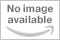

---------------------------------------------------------------------------

[43] Processing junk file: B09JMNBKCQ.jpg
    - Product Identifier (ASIN): B09JMNBKCQ
    - Caption: Aoxjox Trinity Workout Biker Shorts for Women Tummy Control High Waisted Exercise Athletic Gym Running Yoga Shorts 6" (Steel Blue, X-Large)
    - [ACTUAL IMAGE FROM THE DATASET]:


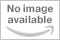

---------------------------------------------------------------------------

[44] Processing junk file: B089SHQ5DP.jpg
    - Product Identifier (ASIN): B089SHQ5DP
    - Caption: SLEITY Llamastay 6 Feet Away Tee Tops Graphic Funny Gift Sweatshirt Shirts for Women Brick Red
    - [ACTUAL IMAGE FROM THE DATASET]:


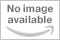

---------------------------------------------------------------------------

[45] Processing junk file: B099ZR84MG.jpg
    - Product Identifier (ASIN): B099ZR84MG
    - Caption: NC Girls Cartoon Print Casual Dress Flutter Pearl Dress for Birthday Party Children toddles Boutique Dress Milksilk1-7 Years
    - [ACTUAL IMAGE FROM THE DATASET]:


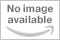

---------------------------------------------------------------------------

[46] Processing junk file: B015QSLGL2.jpg
    - Product Identifier (ASIN): B015QSLGL2
    - Caption: 2 Balance Bracelets, Silicone Beaded Blue White Combo - Medium Size
    - [ACTUAL IMAGE FROM THE DATASET]:


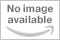

---------------------------------------------------------------------------

[47] Processing junk file: B077TLPSZ3.jpg
    - Product Identifier (ASIN): B077TLPSZ3
    - Caption: S.L. Fashions Women's Sleeveless Tulip Popover Dress, MidTeal, 16
    - [ACTUAL IMAGE FROM THE DATASET]:


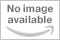

---------------------------------------------------------------------------

[48] Processing junk file: B07ZVC4HJB.jpg
    - Product Identifier (ASIN): B07ZVC4HJB
    - Caption: Winter Leather Gloves For Men Women Touch Screen Driving Lightweight Button Full-Hand Ladies Brown Large
    - [ACTUAL IMAGE FROM THE DATASET]:


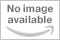

---------------------------------------------------------------------------

[49] Processing junk file: B098D4L242.jpg
    - Product Identifier (ASIN): B098D4L242
    - Caption: GRACE KARIN Women's Turtleneck Long Sleeve Elasticity Knit Bodycon Mini Sweater Dress Blue L
    - [ACTUAL IMAGE FROM THE DATASET]:


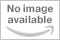

---------------------------------------------------------------------------

[50] Processing junk file: B07T93425Z.jpg
    - Product Identifier (ASIN): B07T93425Z
    - Caption: Winging Day Little Girls Cartoon Soft Hipster Assorted Prints Underwear Size 6 (6-Pack)
    - [ACTUAL IMAGE FROM THE DATASET]:


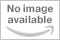

---------------------------------------------------------------------------

[51] Processing junk file: B08LKLTMPN.jpg
    - Product Identifier (ASIN): B08LKLTMPN
    - Caption: YouSexy Women's Plus Size Flare Bell Bottom Jeans Patch Hem Destroyed Flare Denim Pants
    - [ACTUAL IMAGE FROM THE DATASET]:


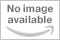

---------------------------------------------------------------------------

[52] Processing junk file: B07FR5MPRC.jpg
    - Product Identifier (ASIN): B07FR5MPRC
    - Caption: LEANI Women's Long Open Front Drape Lightweight Maxi Long Sleeve Cardigan Sweater Longline Duster Coat (Dark Grey, XX-Large)
    - [ACTUAL IMAGE FROM THE DATASET]:


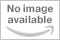

---------------------------------------------------------------------------

[53] Processing junk file: B000WCOXKE.jpg
    - Product Identifier (ASIN): B000WCOXKE
    - Caption: Denali Laptop Bag45; Tan47; Brown Canvas
    - [ACTUAL IMAGE FROM THE DATASET]:


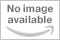

---------------------------------------------------------------------------

[54] Processing junk file: B0965LKSTF.jpg
    - Product Identifier (ASIN): B0965LKSTF
    - Caption: 3D Wolf T Shirts,Print 3D Funny t Shirt,Youth Boys Girls Age 4-14 Years (TK1682, L)
    - [ACTUAL IMAGE FROM THE DATASET]:


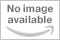

---------------------------------------------------------------------------

[55] Processing junk file: B08J87V5JL.jpg
    - Product Identifier (ASIN): B08J87V5JL
    - Caption: Active Wear Sets-Women's Workout Clothes Gym Wear Track Suits Yoga Jacket Pants Vest 3 Pieces Set Red
    - [ACTUAL IMAGE FROM THE DATASET]:


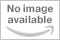

---------------------------------------------------------------------------

[56] Processing junk file: B0894P8SK5.jpg
    - Product Identifier (ASIN): B0894P8SK5
    - Caption: TEMOFON Women's Dresses Summer Floral Wrap Ruffled High Low Short Sleeve V-Neck Bohemian Beach Dress Pink Floral L
    - [ACTUAL IMAGE FROM THE DATASET]:


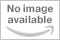

---------------------------------------------------------------------------

[57] Processing junk file: B084NWVT7K.jpg
    - Product Identifier (ASIN): B084NWVT7K
    - Caption: Eileen West Plus Size Floral Scroll-Print Jersey Ballet Nightgown (2X Plus, Viney Floral)
    - [ACTUAL IMAGE FROM THE DATASET]:


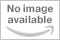

---------------------------------------------------------------------------

[58] Processing junk file: B019TPLF82.jpg
    - Product Identifier (ASIN): B019TPLF82
    - Caption: DH APPLE Women's Bohemian One Shoulder Slim A-line Dress for Holiday (S/M)
    - [ACTUAL IMAGE FROM THE DATASET]:


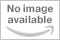

---------------------------------------------------------------------------

[59] Processing junk file: B06XS9QW4G.jpg
    - Product Identifier (ASIN): B06XS9QW4G
    - Caption: YourStyle 3/4 Sleeve Stretch Button Down Shirt (Medium, Royal)
    - [ACTUAL IMAGE FROM THE DATASET]:


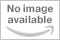

---------------------------------------------------------------------------

➔ COMPLETED: Successfully cleaned up and permanently deleted 59 invalid image files from Drive!


In [ ]:
if 'removed_images_log' in locals() and removed_images_log:
    print("=" * 85)
    print(f"   DETAILED LIST AND REAL IMAGE PREVIEW OF {len(removed_images_log)} REMOVED INVALID FILES")
    print("=" * 85)

    actual_deleted_counter = 0

    for idx, item in enumerate(removed_images_log, 1):
        img_path = item['path']
        print(f"\n[{idx}] Processing junk file: {os.path.basename(img_path)}")
        print(f"    - Product Identifier (ASIN): {item['asin']}")
        print(f"    - Caption: {item['caption']}")

        # Check whether the file still exists before displaying the actual image in Colab
        if os.path.exists(img_path):
            print(f"    - [ACTUAL IMAGE FROM THE DATASET]:")

            try:
                # Load and display the exact invalid image stored in your dataset
                display(IPImage(filename=img_path, width=130))
            except Exception as e:
                print(f"    (Unable to display image preview: {e})")

            # AFTER DISPLAYING -> Permanently delete the physical file to clean up Drive
            try:
                os.remove(img_path)
                actual_deleted_counter += 1
            except Exception as e:
                print(f"    [ERROR] Unable to delete physical file: {e}")
        else:
            print("    - (The physical file was already deleted previously or does not exist)")

        print("-" * 75)

    print(f"\n➔ COMPLETED: Successfully cleaned up and permanently deleted {actual_deleted_counter} invalid image files from Drive!")
else:
    print("Your dataset is completely clean! No invalid images need to be displayed or deleted.")

In [ ]:
CATEGORY = "Amazon_Fashion"
META_PATH = os.path.join(PROJECT_DIR, f'records_{CATEGORY}.json')
with open(META_PATH, 'w') as f:
    json.dump(records, f)
print('Saved metadata to', META_PATH)

Saved metadata to /content/drive/MyDrive/clip_amazon_retrieval/records_Amazon_Fashion.json


## 5. Train / Val split

In [ ]:
import random
random.seed(42)
random.shuffle(records)

VAL_RATIO  = 0.1
TEST_RATIO = 0.1

n_val  = max(64, int(len(records) * VAL_RATIO))
n_test = max(64, int(len(records) * TEST_RATIO))



val_records   = records[:n_val]
test_records  = records[n_val : n_val + n_test]
train_records = records[n_val + n_test:]

print(f'Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}')

Train: 3953 | Val: 494 | Test: 494


## 6. Dataset + DataLoader cho CLIP

In [ ]:
MODEL_NAME = 'openai/clip-vit-base-patch32'
processor  = CLIPProcessor.from_pretrained(MODEL_NAME)

class AmazonCLIPDataset(Dataset):
    def __init__(self, items, processor):
        self.items = items
        self.processor = processor
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        it = self.items[idx]
        try:
            img = Image.open(it['image']).convert('RGB')
        except Exception:
            img = Image.open(self.items[0]['image']).convert('RGB')
            it  = self.items[0]
        return img, it['caption']

def collate_fn(batch):
    images, texts = zip(*batch)
    enc = processor(
        text=list(texts),
        images=list(images),
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=77,
    )
    return enc

BATCH_SIZE   = 32
NUM_WORKERS  = 2

train_ds = AmazonCLIPDataset(train_records, processor)
val_ds   = AmazonCLIPDataset(val_records,   processor)
test_ds = AmazonCLIPDataset(test_records,   processor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True
)

print('Train batches:', len(train_loader), '| Val batches:', len(val_loader), 'Test batches:', len(test_loader))

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

Train batches: 124 | Val batches: 16 Test batches: 16


In [ ]:
MODEL_NAME = 'openai/clip-vit-base-patch32'
processor  = CLIPProcessor.from_pretrained(MODEL_NAME)

class AmazonCLIPDataset(Dataset):
    def __init__(self, items, processor, is_train=True):
        self.items = items
        self.processor = processor
        self.is_train = is_train
        self.keywords_pool = ["shoes", "dress", "shirt", "pants", "jacket", "skirt", "boots", "sneakers", "sandal", "jeans", "shorts", "coat"]

    def __len__(self):
        return len(self.items)

    def _find_hard_negative(self, current_it):
        """Tìm một đường dẫn ảnh tiêu cực khó: Thuộc sản phẩm khác nhưng cố tình né từ khóa chính"""
        caption_lower = current_it['caption'].lower()
        target_keyword = None

        for kw in self.keywords_pool:
            if kw in caption_lower:
                target_keyword = kw
                break

        for _ in range(20):
            candidate = random.choice(self.items)
            if candidate['asin'] == current_it['asin']:
                continue
            if target_keyword and target_keyword in candidate['caption'].lower():
                continue
            return candidate['image']

        return random.choice(self.items)['image']

    def __getitem__(self, idx):
        it = self.items[idx]

        # 1. Đọc ảnh chuẩn (Positive Image)
        try:
            img = Image.open(it['image']).convert('RGB')
        except Exception:
            img = Image.open(self.items[0]['image']).convert('RGB')
            it = self.items[0]

        # 2. Nếu là tập Train, tìm thêm một ảnh Hard Negative
        if self.is_train:
            neg_img_path = self._find_hard_negative(it)
            try:
                neg_img = Image.open(neg_img_path).convert('RGB')
            except Exception:
                neg_img = img
            return img, neg_img, it['caption']

        return img, None, it['caption']

def collate_fn(batch):
    images, neg_images, texts = zip(*batch)

    enc = processor(
        text=list(texts),
        images=list(images),
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=77,
    )

    # Nếu batch thuộc tập Train (có ảnh Hard Negative) -> tokenize riêng ảnh khó
    if neg_images[0] is not None:
        neg_enc = processor(
            images=list(neg_images),
            return_tensors='pt'
        )
        enc['neg_pixel_values'] = neg_enc['pixel_values']

    return enc

BATCH_SIZE   = 32    # Giảm xuống 16 nếu gặp lỗi GPU Out of Memory (OOM)
NUM_WORKERS  = 2

train_ds = AmazonCLIPDataset(train_records, processor, is_train=True)
val_ds   = AmazonCLIPDataset(val_records,   processor, is_train=False)
test_ds  = AmazonCLIPDataset(test_records,  processor, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print('Train batches:', len(train_loader), '| Val batches:', len(val_loader), 'Test batches:', len(test_loader))

Train batches: 124 | Val batches: 16 Test batches: 16


## 7. Khởi tạo model + optimizer

CLIP đã được pretrain trên 400M cặp (image, text). Khi fine-tune trên domain hẹp (Amazon products), dùng learning rate nhỏ để không phá weights gốc.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

baseline_model  = CLIPModel.from_pretrained(MODEL_NAME).to(device)

@torch.no_grad()
def evaluate_recall(baseline_model, loader, ks=(1, 5, 10)):
    baseline_model.eval()
    img_embs, txt_embs = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = baseline_model(**batch)
        img_embs.append(out.image_embeds.float().cpu())
        txt_embs.append(out.text_embeds.float().cpu())

    img_embs = torch.cat(img_embs)
    txt_embs = torch.cat(txt_embs)

    img_embs = img_embs / img_embs.norm(dim=-1, keepdim=True)
    txt_embs = txt_embs / txt_embs.norm(dim=-1, keepdim=True)

    sims = txt_embs @ img_embs.T              # [N_text, N_image]
    targets = torch.arange(sims.size(0))

    results = {}
    for k in ks:
        topk = sims.topk(k, dim=1).indices
        hit = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        results[f'R@{k}'] = hit
    return results

print("Evaluating the original CLIP model (before training)...")
zero_shot_metrics = evaluate_recall(baseline_model, val_loader)

print("="*50)
print(f"[ZERO-SHOT BASELINE] Results on the Validation set:")
for k, v in zero_shot_metrics.items():
    print(f"  - {k}: {v:.4f}")
print("="*50)

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Đang đánh giá mô hình CLIP gốc (chưa qua huấn luyện)...
[ZERO-SHOT BASELINE] Kết quả trên tập Validation:
  - R@1: 0.6194
  - R@5: 0.8644
  - R@10: 0.9130


In [ ]:
zero_shot_metrics = evaluate_recall(baseline_model, test_loader)

print("="*50)
print(f"[ZERO-SHOT BASELINE] Result in Validation set:")
for k, v in zero_shot_metrics.items():
    print(f"  - {k}: {v:.4f}")
print("="*50)


[ZERO-SHOT BASELINE] Kết quả trên tập Validation:
  - R@1: 0.6397
  - R@5: 0.8785
  - R@10: 0.9231


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = CLIPModel.from_pretrained(MODEL_NAME).to(device)

LR              = 1e-6
WEIGHT_DECAY    = 0.1
EPOCHS          = 20
WARMUP_RATIO    = 0.1
GRAD_ACCUM      = 1



optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps  = len(train_loader) * EPOCHS // GRAD_ACCUM
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler  = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler     = torch.cuda.amp.GradScaler()
print('Total optim steps:', total_steps, '| Warmup:', warmup_steps)

Total optim steps: 2480 | Warmup: 248


## 8. Training Loop (Contrastive Loss)

The CLIP loss is calculated as the average cross-entropy loss across both image→text and text→image directions on the batch similarity matrix.  
`CLIPModel` already returns the `loss` when `return_loss=True` is specified.

Epoch 1/20:   0%|          | 0/124 [00:00<?, ?it/s]


[Epoch 1] Train Loss: 0.0281 | Val Loss: 0.2630
[Epoch 1] Recall Metrics: {'R@1': 0.6639676094055176, 'R@5': 0.8805667757987976, 'R@10': 0.931174099445343}
Saved best checkpoint to /content/drive/MyDrive/clip_amazon_retrieval/checkpoints/best


Epoch 2/20:   0%|          | 0/124 [00:00<?, ?it/s]


[Epoch 2] Train Loss: 0.0212 | Val Loss: 0.2604
[Epoch 2] Recall Metrics: {'R@1': 0.6821862459182739, 'R@5': 0.8906882405281067, 'R@10': 0.9372469782829285}
Saved best checkpoint to /content/drive/MyDrive/clip_amazon_retrieval/checkpoints/best


Epoch 3/20:   0%|          | 0/124 [00:00<?, ?it/s]

...


[Epoch 18] Train Loss: 0.0029 | Val Loss: 0.3040
[Epoch 18] Recall Metrics: {'R@1': 0.7085019946098328, 'R@5': 0.9008097052574158, 'R@10': 0.9493927359580994}


Epoch 19/20:   0%|          | 0/124 [00:00<?, ?it/s]


[Epoch 19] Train Loss: 0.0019 | Val Loss: 0.3035
[Epoch 19] Recall Metrics: {'R@1': 0.7064777612686157, 'R@5': 0.9028339982032776, 'R@10': 0.9493927359580994}


Epoch 20/20:   0%|          | 0/124 [00:00<?, ?it/s]


[Epoch 20] Train Loss: 0.0038 | Val Loss: 0.3034
[Epoch 20] Recall Metrics: {'R@1': 0.7085019946098328, 'R@5': 0.9028339982032776, 'R@10': 0.9493927359580994}


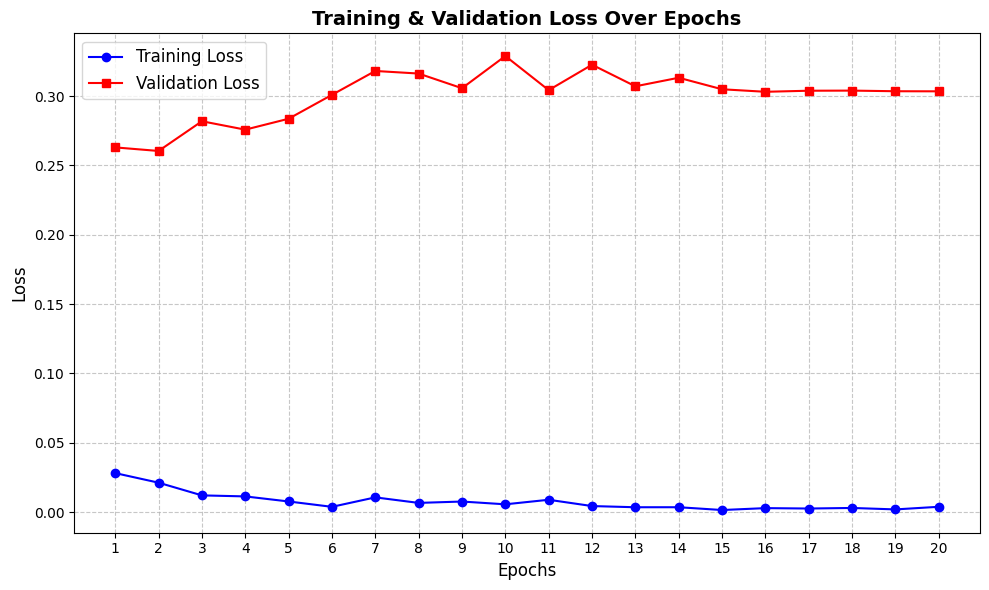

In [ ]:
@torch.no_grad()
def evaluate_recall(model, loader, ks=(1, 5, 10)):
    model.eval()
    img_embs, txt_embs = [], []

    for batch in loader:
        inputs = {k: v.to(device) for k, v in batch.items() if v is not None and k != 'neg_pixel_values'}

        out = model(**inputs)
        img_embs.append(out.image_embeds.float().cpu())
        txt_embs.append(out.text_embeds.float().cpu())

    img_embs = torch.cat(img_embs)
    txt_embs = torch.cat(txt_embs)

    img_embs = img_embs / img_embs.norm(dim=-1, keepdim=True)
    txt_embs = txt_embs / txt_embs.norm(dim=-1, keepdim=True)

    sims = txt_embs @ img_embs.T
    targets = torch.arange(sims.size(0))

    results = {}
    for k in ks:
        topk = sims.topk(k, dim=1).indices
        hit = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item()
        results[f'R@{k}'] = hit
    return results

@torch.no_grad()
def evaluate_loss(model, loader):
    """Hàm tính toán Validation Loss."""
    model.eval()
    total_loss = 0.0

    for batch in loader:
        inputs = {k: v.to(device) for k, v in batch.items() if v is not None and k != 'neg_pixel_values'}

        with torch.cuda.amp.autocast():
            out = model(**inputs, return_loss=True)
            loss = out.loss

        total_loss += loss.item()

    return total_loss / len(loader)

best_r1 = 0.0
global_step = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items() if v is not None}

        with torch.cuda.amp.autocast():
            if 'neg_pixel_values' in batch:
                text_features = model.get_text_features(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
                image_features = model.get_image_features(pixel_values=batch['pixel_values'])
                neg_image_features = model.get_image_features(pixel_values=batch['neg_pixel_values'])

                text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                neg_image_features = neg_image_features / neg_image_features.norm(dim=-1, keepdim=True)

                logit_scale = model.logit_scale.exp()

                pos_logits = torch.sum(text_features * image_features, dim=-1) * logit_scale
                neg_logits = torch.sum(text_features * neg_image_features, dim=-1) * logit_scale

                logits = torch.stack([pos_logits, neg_logits], dim=-1)
                labels = torch.zeros(logits.shape[0], dtype=torch.long).to(device)
                loss = torch.nn.functional.cross_entropy(logits, labels)
            else:
                out = model(**batch, return_loss=True)
                loss = out.loss

            loss = loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        running_loss += loss.item() * GRAD_ACCUM
        pbar.set_postfix(loss=f'{running_loss/(step+1):.4f}',
                         lr=f'{scheduler.get_last_lr()[0]:.2e}')

    # 1. Calculate the average Train/Validation Loss at the end of each epoch for logging
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = evaluate_loss(model, val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"\n[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # 2. Đánh giá độ chính xác (Recall) trên tập Validation sau mỗi Epoch
    metrics = evaluate_recall(model, val_loader)
    print(f'[Epoch {epoch+1}] Recall Metrics:', metrics)

    # 2. Evaluate the accuracy (Recall) on the Validation set after each epoch
    if metrics['R@1'] > best_r1:
        best_r1 = metrics['R@1']
        save_dir = os.path.join(CKPT_DIR, 'best')
        model.save_pretrained(save_dir)
        processor.save_pretrained(save_dir)
        print('Saved best checkpoint to', save_dir)



epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'b-', label='Training Loss', marker='o')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss', marker='s')

plt.title('Training & Validation Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [ ]:
evaluate_recall(model, test_loader, ks=(1, 5, 10))

{'R@1': 0.659919023513794,
 'R@5': 0.9028339982032776,
 'R@10': 0.9514170289039612}

In [ ]:
@torch.no_grad()
def evaluate_ndcg(model, loader, ks=(1, 5, 10)):
    model.eval()

    img_embs = []
    txt_embs = []

    # =========================
    # Extract embeddings
    # =========================
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(**batch)

        img_embs.append(out.image_embeds.float().cpu())
        txt_embs.append(out.text_embeds.float().cpu())

    img_embs = torch.cat(img_embs)
    txt_embs = torch.cat(txt_embs)

    # Normalize
    img_embs = img_embs / img_embs.norm(dim=-1, keepdim=True)
    txt_embs = txt_embs / txt_embs.norm(dim=-1, keepdim=True)

    # Similarity matrix
    sims = txt_embs @ img_embs.T

    targets = torch.arange(sims.size(0))

    results = {}

    for k in ks:

        topk = sims.topk(k, dim=1).indices

        ndcg_scores = []

        for i in range(sims.size(0)):

            ranking = topk[i]

            # relevance vector
            rel = (ranking == targets[i]).float()

            # DCG
            dcg = 0.0
            for rank_idx, r in enumerate(rel):
                dcg += r.item() / torch.log2(torch.tensor(rank_idx + 2)).item()

            # IDCG = ideal ranking
            idcg = 1.0  # correct item ideally at rank 1

            ndcg = dcg / idcg

            ndcg_scores.append(ndcg)

        results[f'NDCG@{k}'] = sum(ndcg_scores) / len(ndcg_scores)

    return results

In [ ]:
evaluate_ndcg(model, test_loader)

In [ ]:
evaluate_ndcg(baseline_model, test_loader)